In [1]:
import datasets
import numpy as np
import pandas as pd

from datasets import load_dataset
from pathlib import Path
from sentence_transformers import SentenceTransformer

In [2]:
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
from tiny.datasets import (
    ARCDatasetLoader,
    BioASQDatasetLoader,
    OBQADatasetLoader,
    PIQADatasetLoader,
    PubMedQADatasetLoader,
    RiddleDatasetLoader,
)

In [4]:
DATASET_ROOT = Path('..', 'datasets')

In [5]:
def load_from_json(dataset_name, dataset_folder=DATASET_ROOT):
    data_files = {
        'train' : f'{dataset_folder}/{dataset_name}/{dataset_name}_train.json',
        'test' : f'{dataset_folder}/{dataset_name}/{dataset_name}_test.json',
    }

    valid_file_path = f'{dataset_folder}/{dataset_name}/{dataset_name}_valid.json'

    if Path(valid_file_path).exists():
        data_files['valid'] = valid_file_path

    return load_dataset('json', data_files=data_files)

In [6]:
for file in DATASET_ROOT.iterdir():
    print(file.name)

bioasq
obqa
riddle
piqa
arc
pubmedqa


In [7]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [8]:
dataset_name = 'bioasq'

In [9]:
basic = load_from_json(dataset_name)

Using custom data configuration default-96eda7dc077599c7
Found cached dataset json (/home/gagodoi@posgrad.usricmc.icmc.usp.br/.cache/huggingface/datasets/json/default-96eda7dc077599c7/0.0.0/f4e89e8750d5d5ffbef2c078bf0ddfedef29dc2faff52a6255cf513c05eb1092)


In [10]:
if dataset_name == 'riddle':
    loader = RiddleDatasetLoader()
elif dataset_name == 'arc':
    loader = ARCDatasetLoader()
elif dataset_name == 'bioasq':
    loader = BioASQDatasetLoader()
elif dataset_name == 'obqa':
    loader = OBQADatasetLoader()
elif dataset_name == 'piqa':
    loader = PIQADatasetLoader()
elif dataset_name == 'pubmedqa':
    loader = PubMedQADatasetLoader()
else:
    raise ValueError(f"Unknown dataset_name: {dataset_name}")

loader.data_root = DATASET_ROOT

ds = loader.load_from_json()

rationales = loader.load_llm_preds(split='train')

Using custom data configuration default-96eda7dc077599c7
Found cached dataset json (/home/gagodoi@posgrad.usricmc.icmc.usp.br/.cache/huggingface/datasets/json/default-96eda7dc077599c7/0.0.0/f4e89e8750d5d5ffbef2c078bf0ddfedef29dc2faff52a6255cf513c05eb1092)
Loading cached processed dataset at /home/gagodoi@posgrad.usricmc.icmc.usp.br/.cache/huggingface/datasets/json/default-96eda7dc077599c7/0.0.0/f4e89e8750d5d5ffbef2c078bf0ddfedef29dc2faff52a6255cf513c05eb1092/cache-474e623631369f90_*_of_00001.arrow
Loading cached processed dataset at /home/gagodoi@posgrad.usricmc.icmc.usp.br/.cache/huggingface/datasets/json/default-96eda7dc077599c7/0.0.0/f4e89e8750d5d5ffbef2c078bf0ddfedef29dc2faff52a6255cf513c05eb1092/cache-934b2c71886843df_*_of_00001.arrow
Loading cached processed dataset at /home/gagodoi@posgrad.usricmc.icmc.usp.br/.cache/huggingface/datasets/json/default-96eda7dc077599c7/0.0.0/f4e89e8750d5d5ffbef2c078bf0ddfedef29dc2faff52a6255cf513c05eb1092/cache-56726d6102e96f22_*_of_00001.arrow


In [11]:
ds
# ds['train'][1]

DatasetDict({
    train: Dataset({
        features: ['input', 'label'],
        num_rows: 976
    })
    test: Dataset({
        features: ['input', 'label'],
        num_rows: 123
    })
    valid: Dataset({
        features: ['input', 'label'],
        num_rows: 109
    })
})

In [13]:
ds['train'][1]

{'input': 'In addition, Sir2 overexpression prevents Rif1 deletion from disrupting Sir2 at IGS1 and shortening lifespan.  \n Roles for sirtuin proteins at telomeres are thought to promote lifespan in yeast and mammals. \n Overexpression of sirtuins (NAD(+)-dependent protein deacetylases) has been reported to increase lifespan in budding yeast (Saccharomyces cerevisiae) \n When overexpressed, the NAD-dependent protein deacetylase Sir2 extends the lifespan of both budding yeast  \n When overexpressed in primary mouse embryo fibroblasts (MEFs), SIRT1 antagonizes PML-induced acetylation of p53 and rescues PML-mediated premature cellular senescence.  \n Has overexpression of sirtuins been reported to increase lifespan in budding yeast (Saccharomyces cerevisiae)?\nAnswer Choices:\n(a) yes\n(b) no',
 'label': 'yes'}

In [12]:
basic['train'][1]

{'id': '52b2e97df828ad283c000012',
 'question': 'In addition, Sir2 overexpression prevents Rif1 deletion from disrupting Sir2 at IGS1 and shortening lifespan.  \n Roles for sirtuin proteins at telomeres are thought to promote lifespan in yeast and mammals. \n Overexpression of sirtuins (NAD(+)-dependent protein deacetylases) has been reported to increase lifespan in budding yeast (Saccharomyces cerevisiae) \n When overexpressed, the NAD-dependent protein deacetylase Sir2 extends the lifespan of both budding yeast  \n When overexpressed in primary mouse embryo fibroblasts (MEFs), SIRT1 antagonizes PML-induced acetylation of p53 and rescues PML-mediated premature cellular senescence.  \n Has overexpression of sirtuins been reported to increase lifespan in budding yeast (Saccharomyces cerevisiae)?',
 'choices': ['yes', 'no'],
 'answer': 'yes'}

In [18]:
print(rationales[0][1])
print()
print(rationales[1][1])
print()
print(rationales[2][1])

Let's think step by step. Yes, Overexpression of sirtuins (NAD(+)-dependent protein deacetylases) has been reported to increase lifespan in budding yeast (Saccharomyces cerevisiae).

yes

Let's think step by step.
The passage states that Sir2 overexpression prevents Rif1 deletion from disrupting Sir2 at IGS1 and shortening lifespan. This implies that Sir2 overexpression has a protective effect on lifespan.
The passage also mentions that overexpression of sirtuins (NAD(+)-dependent protein deacetylases) has been reported to increase lifespan in budding yeast.
Therefore, the answer is (a)


In [19]:
embeddings_A = model.encode(rationales[0])
embeddings_B = model.encode(rationales[2])

def cosine_similarity(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

similarities = [
    cosine_similarity(a, b)
    for a, b in zip(embeddings_A, embeddings_B)
]

In [20]:
df = pd.DataFrame({
    'rationale_A' : rationales[0],
    'rationale_B' : rationales[2],
    'similarity'  : similarities,
    'length_A' : [len(a) for a in rationales[0]],
    'length_B' : [len(b) for b in rationales[2]],
})

df.head()

,rationale_A,rationale_B,similarity,length_A,length_B
0,"Let's think step by step. Yes, Tuberous Sclero...",Let's think step by step.\n1. Tuberous scleros...,0.919315,250,336
1,"Let's think step by step. Yes, Overexpression ...",Let's think step by step.\nThe passage states ...,0.815124,181,405
2,"Let's think step by step. Yes, Levoxyl (levoth...","Let's think step by step.\nIn the passage, it ...",0.609267,81,341
3,"Let's think step by step. Yes, FOXO transcript...","Let's think step by step..\nIn the passage, it...",0.736642,146,396
4,"Let's think step by step. Yes, mutations in th...","Let's think step by step..\n* ""Charcot-Marie-T...",0.809811,132,337


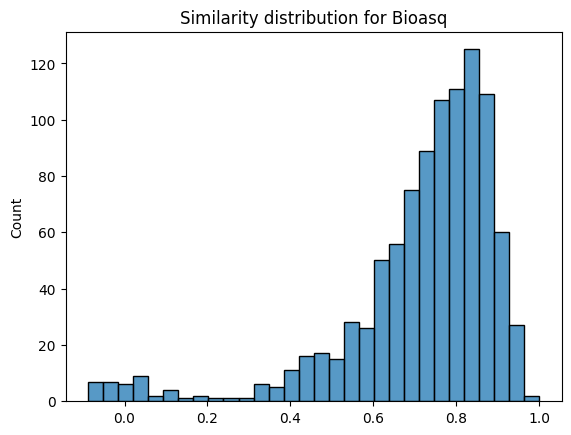

In [ ]:
sns.histplot(similarities)
plt.title(f"Similarity distribution for {dataset_name.title()}")
plt.savefig(Path('..', 'outputs', 'charts', f'similarity_distribution_{dataset_name}.png'))

In [23]:
# df[
#     df['length_B'] == 0
# ]

df[
    df['similarity'] < 0.0
]

,rationale_A,rationale_B,similarity,length_A,length_B
52,Let's think step by step.,Let's think step by step..\nThe text states th...,-0.044408,25,413
87,"Let's think step by step. Yes, the PTPN22 gene...",nan,-0.079207,87,3
153,"Let's think step by step. Yes, Notch mutations...",Let's think step by step.,-0.000413,106,25
166,"Let's think step by step. Yes, there is a link...",Let's think step by step.,-0.055466,103,25
238,Let's think step by step.,Let's think step by step.. The passage states ...,-0.049057,25,472
263,"Let's think step by step. Yes, NOD1 is an intr...",nan,-0.021880,332,3
278,"Let's think step by step. Yes, RG7112 binds MD...",nan,-0.052502,131,3
279,"Let's think step by step. Yes, reduced nicotin...",Let's think step by step.,-0.020775,188,25
291,"Let's think step by step. Yes, RG7112 is a pot...",nan,-0.086262,196,3
313,"Let's think step by step. Yes, there is an ass...",Let's think step by step.,-0.030465,118,25


In [253]:
df[
    df['length_A'] < 50
]

,rationale_A,rationale_B,similarity,length_A,length_B
12,Hawkins sign is a sign of avascular necrosis.,Let's think step by step.\nThe Hawkins sign is...,0.804904,45,358
62,nan,Let's think step by step.\n(a) Yes:\nThe aim o...,-0.015576,3,369
122,The RVEF remained unchanged after PVR.,Let's think step by step.\nWhat is the purpose...,0.275436,38,410
129,INR is not reliable in general practice.,"Let's think step by step.\nFirst, we have to f...",0.371646,40,394
150,Symptoms are not a good predictor of COPD.,Let's think step by step.\n1. COPD is a common...,0.605559,42,370
258,HINT1 is not a candidate gene for schizophrenia.,Let's think step by step.\n\n1. 8 SNPs around ...,0.718717,48,338
262,nan,Let's think step by step.\nThe question is:\nD...,-0.073392,3,336
299,Hearing loss is a complication of pre-eclampsia.,Let's think step by step.\n**Step 1:** What ar...,0.681335,48,349
